## Initialization

In [ ]:
from torch.func import vjp
import torch
from torch.func import jacrev, functional_call
import torch.nn as nn
from torch import Tensor

import torch.nn.functional as F

import matplotlib.pyplot as plt

In [ ]:
import sys
import os

current_notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, '../../'))

# 将这个父目录添加到sys.path的最前面
if project_root_dir not in sys.path:
    sys.path.insert(0, project_root_dir)

print(sys.path)

In [ ]:
import gc, sys, torch, traceback


def recover_cuda_after_oom():
    # 1️⃣ 清掉异常栈引用
    sys.last_traceback = None
    sys.last_value = None
    sys.last_type = None
    
    # 2️⃣ 清掉交互式变量（等价于清 _ 和 __ 的引用）
    for name in ["_", "__"]:
        if name in globals():
            globals()[name] = None
    
    # 3️⃣ 回收 Python 层的对象
    print(gc.collect())
    
    # 4️⃣ 清空 PyTorch CUDA 缓存
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
    print("✅ CUDA 显存已尝试回收")

# 用法：函数报 OOM 后调用
recover_cuda_after_oom()

In [ ]:
import torch
import torch.nn as nn
from torch.func import functional_call, grad, vmap

# 核心功能函数
def compute_param_gradients(model: nn.Module, 
								 inputs: torch.Tensor, 
								 labels: torch.Tensor, 
								 loss_fn = nn.CrossEntropyLoss(reduction='none'), 
								 device='cuda') -> dict:
	"""
	计算每个样本对模型参数的梯度。
	"""
	model.eval()
	model.to(device)
	inputs, labels = inputs.to(device), labels.to(device)

	# 确保损失函数是 reduction='none' 模式
	if loss_fn.reduction != 'none':
		loss_fn = type(loss_fn)(reduction='none')

	params = dict(model.named_parameters())
	buffers = dict(model.named_buffers())

	# 定义一个用于计算单个样本损失的函数
	def single_sample_loss(params_, x, y):
		outputs = functional_call(model, (params_, buffers), x.unsqueeze(0))
		loss = loss_fn(outputs, y.unsqueeze(0))
		return loss.sum() # 确保是标量

	# 获取计算单个样本梯度的函数
	grad_fn = grad(single_sample_loss)

	# 使用 vmap 批量计算每个样本的梯度
	# 为了让cuda不要out of memory, 这里选用vmap而不用jacrev
	grads = vmap(grad_fn, in_dims=(None, 0, 0))(params, inputs, labels)

	return grads

In [ ]:
def flatten_grads_dict(grads):
	return torch.cat(tuple(grad.flatten(1) for grad in grads.values()), dim=1)

In [ ]:
import heapq
from tqdm import tqdm
from torch.utils.data import DataLoader

@torch.no_grad()
def get_topk_loss_sample(model, ds, loss_fn, k, batch_size=512, device='cuda'):
	dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
	idx_offset = 0

	model.eval()
	model.to(device)
	heap = []
	for inputs, labels in tqdm(dl):
		inputs = inputs.to(device)
		labels = labels.to(device)

		outputs = model(inputs)
		losses = loss_fn(outputs, labels)

		batch_losses = [(loss.item(), idx_offset + j) for j, loss in enumerate(losses)]
		for loss, idx in batch_losses:
			if len(heap) < k:
				heapq.heappush(heap, (loss, idx))
			else:
				heapq.heappushpop(heap, (loss, idx))
		
		idx_offset += len(inputs)

	return sorted(heap, key=lambda x: x[0], reverse=True)

In [ ]:
from loss_distribution.pytorch_script.visual_utils \
	import load_cifar10_data, load_model_state_dict

import torchvision
import torchvision.transforms as transforms

In [ ]:
data_pth = '/home/hqdeng7/lijuyang/generalization/loss_distribution/pytorch_script/data/cifar10'
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
train_ds = torchvision.datasets.CIFAR10(root=data_pth, train=True, download=True, transform=transform)
test_ds = torchvision.datasets.CIFAR10(root=data_pth, train=False, download=True, transform=transform)

In [ ]:
model_path = '/home/hqdeng7/lijuyang/generalization/loss_distribution/model_training_results/cifar10_resnet20/model_200.pth'
model = load_model_state_dict('cifar10', 'resnet20', 10, model_path, 'cuda')

In [ ]:
train_hloss_samples = get_topk_loss_sample(model, train_ds, nn.CrossEntropyLoss(reduction='none'), 16)
test_hloss_samples = get_topk_loss_sample(model, test_ds, nn.CrossEntropyLoss(reduction='none'), 16)

In [ ]:
import torchvision.transforms as T
import numpy as np
from PIL import Image

def inverse_trans_cifar10(tensor_img):
	mean, std = (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
	
	for t, m, s in zip(tensor_img, mean, std):
		t.mul_(s).add_(m)
	tensor_img = torch.clamp(tensor_img, 0, 1)
	
	# 转成numpy数组，shape (H,W,C)
	np_img = tensor_img.mul(255).byte().permute(1, 2, 0).cpu().numpy()
	# 转PIL
	pil_img = Image.fromarray(np_img)
	return pil_img

def img_show(img, ax):
	img_np = np.array(img)
	ax.imshow(img_np)
	ax.axis('off')
	return ax

In [ ]:


fig, axes = plt.subplots(4, 4, figsize=(2,2))
axes = axes.flatten()

for i in range(16):
	sample_idx = train_hloss_samples[i][1]
	img = inverse_trans_cifar10(train_ds[sample_idx][0])

	img_show(img, ax=axes[i])

## Grad inner prod

In [ ]:
import torch
import heapq
from torch.utils.data import DataLoader

def find_topk_similar_grad_samples(
	model, 
	ref_input, ref_label, 
	target_ds, 
	k=16,
	loss_fn=nn.CrossEntropyLoss(reduction='none'), 
	device='cuda', batch_size=128
):
	
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')

	# 计算参考样本梯度
	ref_input = ref_input.to(device).unsqueeze(0)
	ref_label = torch.tensor(ref_label).to(device).unsqueeze(0)

	g_ref_dict = compute_param_gradients(model, ref_input, ref_label, loss_fn, device)
	g_ref = flatten_grads_dict(g_ref_dict)[0]  # shape: [D]

	dataloader = DataLoader(target_ds, batch_size=batch_size, shuffle=False)

	heap = []
	idx_offset = 0
	for inputs, labels in tqdm(dataloader):
		inputs = inputs.to(device)
		labels = labels.to(device)

		grads_dict = compute_param_gradients(model, inputs, labels, loss_fn, device)
		grads_flat = flatten_grads_dict(grads_dict)  # [B, D]

		# 计算与参考样本梯度的内积，shape [B]
		grad_inner_prods = grads_flat @ g_ref

		batch_inner_prods = [(prod.item(), idx_offset+i) \
					   for i, prod in enumerate(grad_inner_prods)]

		for prod, idx in batch_inner_prods:
			if len(heap) < k:
				heapq.heappush(heap, (prod, idx))
			else:
				heapq.heappushpop(heap, (prod, idx))
		
		idx_offset += len(inputs)

	heap.sort(key=lambda x: x[0], reverse=True)

	return heap		

In [ ]:
sample_loss_rank = 7
ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = train_ds[ref_sample_idx]
target_ds = train_ds

sim_samples = find_topk_similar_grad_samples(model, ref_input, ref_label, target_ds, 
												   batch_size=512)

In [ ]:
cifar10_cls = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',     
    'dog', 'frog', 'horse', 'ship', 'truck'
]

@torch.no_grad()
def eval_samples(
	model: nn.Module, inputs: Tensor, labels: Tensor, 
	loss_fn = nn.CrossEntropyLoss(reduction='none'), 
	device='cuda'):

	loss_fn = loss_fn if loss_fn.reduction == 'none' \
					else type(loss_fn)(reduction='none')

	inputs = inputs.to(device)
	labels = labels.to(device)
	model = model.to(device)
	model.eval()

	outputs = model(inputs)
	losses = loss_fn(outputs, labels)
	pred_labels = torch.argmax(outputs, dim=1)

	return losses, pred_labels

In [ ]:
ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = train_ds[ref_sample_idx]

plt.figure(figsize=(4, 4))
img = inverse_trans_cifar10(ref_input)
plt.imshow(img)
plt.axis('off')
plt.show()


fig, axes = plt.subplots(4, 4, figsize=(8,8))
axes = axes.flatten()
for i in range(16):
	sample_idx = sim_samples[i][1]
	img = inverse_trans_cifar10(train_ds[sample_idx][0])

	img_show(img, ax=axes[i])


# 取出16个样本的 index
sim_sample_indices = [sim_samples[i][1] for i in range(16)]

# 从数据集取出图像和标签
imgs, labels = zip(*[train_ds[idx] for idx in sim_sample_indices])
imgs = torch.stack(imgs)     # shape: (16, C, H, W)
labels = torch.tensor(labels) # shape: (16,)

# 批量评估
losses, pred_labels = eval_samples(model, imgs, labels)

# 打印结果
for i in range(16):
    print(f'loss: {losses[i]:.4f}' +
          f'    true: {cifar10_cls[labels[i].item()]}' +
          f'    pred: {cifar10_cls[pred_labels[i].item()]}')

In [ ]:
sim_samples

### plot_grad_sim

In [ ]:
def eval_single(model, input, label : int, device='cuda'):
	# 增加 batch 维度
	input_ = input.unsqueeze(0)   # (1, C, H, W)
	label_ = torch.tensor([label], dtype=torch.long)  # (1,)

	# 调用函数
	loss, pred_label = eval_samples(model, input_, label_, device=device)

	return loss.item(), pred_label.item()


def plot_grad_sim(model, ref_input, ref_label, 
				  target_ds, batch_size=512, device='cuda',
				  sim_function=find_topk_similar_grad_samples,
				  print_sims = False):
	sim_samples = sim_function(model, ref_input, ref_label, target_ds, 
													batch_size=batch_size, device=device)
	if print_sims:
		for i in range(16):
			print(sim_samples[i][0])
	
	loss, pred_label = eval_single(model, ref_input, ref_label, device=device)
	
	# 画出原图
	img = inverse_trans_cifar10(ref_input)
	print(f'loss: {loss:.4f}' + \
		'    true label: ' + cifar10_cls[ref_label] + \
		'    pred label: ' + cifar10_cls[pred_label])
	plt.figure(figsize=(4, 4))
	plt.imshow(img)
	plt.axis('off')
	plt.show()

	# 画出16个sim图
	fig, axes = plt.subplots(4, 4, figsize=(8,8))
	axes = axes.flatten()
	for i in range(16):
		sample_idx = sim_samples[i][1]
		img = inverse_trans_cifar10(target_ds[sample_idx][0])

		img_show(img, ax=axes[i])

	# 打印信息
	sim_sample_indices = [sim_samples[i][1] for i in range(16)]

	imgs, labels = zip(*[target_ds[idx] for idx in sim_sample_indices])
	imgs = torch.stack(imgs)     # shape: (16, C, H, W)
	labels = torch.tensor(labels) # shape: (16,)

	# 批量评估
	losses, pred_labels = eval_samples(model, imgs, labels)

	# 打印结果
	for i in range(16):
		print(f'loss: {losses[i]:.4f}' +
			f'    true: {cifar10_cls[labels[i].item()]}' +
			f'    pred: {cifar10_cls[pred_labels[i].item()]}')


In [ ]:
sample_loss_rank = 0
ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = train_ds[ref_sample_idx]
eval_single(model, ref_input, ref_label)

In [ ]:
sample_loss_rank = 0
ref = 'train'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 0
ref = 'train'
target_ds = test_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 10
ref = 'test'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 10
ref = 'test'
target_ds = test_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 7
ref = 'train'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 7
ref = 'train'
target_ds = test_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 9
ref = 'test'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 9
ref = 'test'
target_ds = test_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

## Cosine Similarity

In [ ]:
def find_topk_gradcos_samples(
	model, 
	ref_input, ref_label, 
	target_ds, 
	k=16,
	loss_fn=nn.CrossEntropyLoss(reduction='none'), 
	device='cuda', batch_size=128
):
	
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')

	# 计算参考样本梯度
	ref_input = ref_input.to(device).unsqueeze(0)
	ref_label = torch.tensor(ref_label).to(device).unsqueeze(0)

	g_ref_dict = compute_param_gradients(model, ref_input, ref_label, loss_fn, device)
	g_ref = flatten_grads_dict(g_ref_dict)[0]  # shape: [D]

	dataloader = DataLoader(target_ds, batch_size=batch_size, shuffle=False)

	heap = []
	idx_offset = 0
	for inputs, labels in tqdm(dataloader):
		inputs = inputs.to(device)
		labels = labels.to(device)

		grads_dict = compute_param_gradients(model, inputs, labels, loss_fn, device)
		grads_flat = flatten_grads_dict(grads_dict)  # [B, D]

		# 计算与参考样本梯度的cos sim，shape [B]
		grad_inner_prods = F.cosine_similarity(grads_flat, g_ref.unsqueeze(0), dim=1)

		batch_inner_prods = [(prod.item(), idx_offset+i) \
					   for i, prod in enumerate(grad_inner_prods)]

		for prod, idx in batch_inner_prods:
			if len(heap) < k:
				heapq.heappush(heap, (prod, idx))
			else:
				heapq.heappushpop(heap, (prod, idx))
		
		idx_offset += len(inputs)

	heap.sort(key=lambda x: x[0], reverse=True)

	return heap

In [ ]:
sample_loss_rank = 9
ref = 'test'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]

plot_grad_sim(model, ref_input, ref_label, target_ds, sim_function=find_topk_gradcos_samples)

In [ ]:
sample_loss_rank = 0
ref = 'train'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]

plot_grad_sim(model, ref_input, ref_label, target_ds, sim_function=find_topk_gradcos_samples)

In [ ]:
train_hloss_samples

In [ ]:
test_hloss_samples

In [ ]:
sample_loss_rank = 0
ref = 'train'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]

plot_grad_sim(model, ref_input, ref_label, target_ds, sim_function=find_topk_gradcos_samples, print_sims=True)

In [ ]:
sample_loss_rank = 0
ref = 'train'
target_ds = test_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]

plot_grad_sim(model, ref_input, ref_label, target_ds, sim_function=find_topk_gradcos_samples)

In [ ]:
sample_loss_rank = 10
ref = 'test'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]

plot_grad_sim(model, ref_input, ref_label, target_ds, sim_function=find_topk_gradcos_samples, print_sims=True)

In [ ]:
sample_loss_rank = 7
ref = 'train'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]

plot_grad_sim(model, ref_input, ref_label, target_ds, sim_function=find_topk_gradcos_samples, print_sims=True)

## 函数式尝试

In [13]:
def find_topk_samples(
	ds, 
	fn,
	k=16,
	batch_size=256,
):
	
	dl = DataLoader(ds, batch_size=batch_size, shuffle=False)

	heap = []
	idx_offset = 0
	for batch in tqdm(dl):

		batch_res = fn(batch)
		batch_res_idx = [ (res, idx_offset+i) for i, res in enumerate(batch_res)]

		for res_idx in batch_res_idx:
			if len(heap) < k:
				heapq.heappush(heap, res_idx)
			else:
				heapq.heappushpop(heap, res_idx)
		
		idx_offset += len(batch[0])

	heap.sort(key=lambda x: x[0], reverse=True)

	return heap

In [14]:
@torch.no_grad()
def get_batch_loss_fn(model, loss_fn=nn.CrossEntropyLoss(reduction='none'), device='cuda'):
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')
	model = model.to(device)
	def f(batch):
		inputs, labels = batch
		inputs, labels = inputs.to(device), labels.to(device)
		outputs = model(inputs)
		losses =  loss_fn(outputs, labels)
		return losses.detach().cpu().tolist() 
	return f

hloss_test_samples = find_topk_samples(test_ds, get_batch_loss_fn(model), k=128)
print(len(hloss_test_samples))

100%|██████████| 40/40 [00:02<00:00, 18.19it/s]

128


In [15]:
@torch.no_grad()
def get_batch_grad_prod_fn(model, 
						   ref_input, ref_label,
						   loss_fn=nn.CrossEntropyLoss(reduction='none'), 
						   device='cuda'):
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')
	model = model.to(device)

	ref_input = ref_input.to(device).unsqueeze(0)
	ref_label = torch.tensor(ref_label).to(device).unsqueeze(0)

	g_ref_dict = compute_param_gradients(model, ref_input, ref_label, loss_fn, device)
	g_ref = flatten_grads_dict(g_ref_dict)[0]  # shape: [D]

	def f(batch):
		inputs, labels = batch
		inputs, labels = inputs.to(device), labels.to(device)

		grads_dict = compute_param_gradients(model, inputs, labels, loss_fn, device)
		grads_flat = flatten_grads_dict(grads_dict)  # [B, D]

		# 计算与参考样本梯度的内积，shape [B]
		grad_inner_prods = grads_flat @ g_ref
		return grad_inner_prods.detach().cpu().tolist() 
	return f

In [16]:
sample_loss_rank = 7
ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = train_ds[ref_sample_idx]
target_ds = train_ds

f = get_batch_grad_prod_fn(model, ref_input, ref_label)

sim_samples = find_topk_samples(target_ds, f, batch_size=256)

100%|██████████| 391/391 [00:23<00:00, 16.66it/s]


In [17]:
cifar10_cls = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',     
    'dog', 'frog', 'horse', 'ship', 'truck'
]

@torch.no_grad()
def eval_samples(
	model: nn.Module, inputs: Tensor, labels: Tensor, 
	loss_fn = nn.CrossEntropyLoss(reduction='none'), 
	device='cuda'):

	loss_fn = loss_fn if loss_fn.reduction == 'none' \
					else type(loss_fn)(reduction='none')

	inputs = inputs.to(device)
	labels = labels.to(device)
	model = model.to(device)
	model.eval()

	outputs = model(inputs)
	losses = loss_fn(outputs, labels)
	pred_labels = torch.argmax(outputs, dim=1)

	return losses, pred_labels

def eval_single(model, input, label : int, device='cuda'):
	# 增加 batch 维度
	input_ = input.unsqueeze(0)   # (1, C, H, W)
	label_ = torch.tensor([label], dtype=torch.long)  # (1,)

	# 调用函数
	loss, pred_label = eval_samples(model, input_, label_, device=device)

	return loss.item(), pred_label.item()


def plot_topk_info( target_ds, fn, 
			   batch_size=512, device='cuda', print_sims = False):
	sim_samples = find_topk_samples(target_ds, fn, k = 16, batch_size = batch_size)
	
	if print_sims:
		for i in range(16):
			print(sim_samples[i][0])
	
	loss, pred_label = eval_single(model, ref_input, ref_label, device=device)
	
	# 画出原图
	img = inverse_trans_cifar10(ref_input)
	print(f'loss: {loss:.4f}' + \
		'    true label: ' + cifar10_cls[ref_label] + \
		'    pred label: ' + cifar10_cls[pred_label])
	plt.figure(figsize=(4, 4))
	plt.imshow(img)
	plt.axis('off')
	plt.show()

	# 画出16个sim图
	fig, axes = plt.subplots(4, 4, figsize=(8,8))
	axes = axes.flatten()
	for i in range(16):
		sample_idx = sim_samples[i][1]
		img = inverse_trans_cifar10(target_ds[sample_idx][0])

		img_show(img, ax=axes[i])

	# 打印信息
	sim_sample_indices = [sim_samples[i][1] for i in range(16)]

	imgs, labels = zip(*[target_ds[idx] for idx in sim_sample_indices])
	imgs = torch.stack(imgs)     # shape: (16, C, H, W)
	labels = torch.tensor(labels) # shape: (16,)

	# 批量评估
	losses, pred_labels = eval_samples(model, imgs, labels)

	# 打印结果
	for i in range(16):
		print(f'loss: {losses[i]:.4f}' +
			f'    true: {cifar10_cls[labels[i].item()]}' +
			f'    pred: {cifar10_cls[pred_labels[i].item()]}')

	return sim_sample_indices

In [18]:
def get_batch_grad_cos_fn(model, 
						   ref_input, ref_label,
						   loss_fn=nn.CrossEntropyLoss(reduction='none'), 
						   device='cuda'):
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')
	model = model.to(device)

	ref_input = ref_input.to(device).unsqueeze(0)
	ref_label = torch.tensor(ref_label).to(device).unsqueeze(0)

	g_ref_dict = compute_param_gradients(model, ref_input, ref_label, loss_fn, device)
	g_ref = flatten_grads_dict(g_ref_dict)[0]  # shape: [D]

	def f(batch):
		inputs, labels = batch
		inputs, labels = inputs.to(device), labels.to(device)

		grads_dict = compute_param_gradients(model, inputs, labels, loss_fn, device)
		grads_flat = flatten_grads_dict(grads_dict)  # [B, D]

		# 计算与参考样本梯度的内积，shape [B]
		batch_gradcos = F.cosine_similarity(grads_flat, g_ref.unsqueeze(0), dim=1)
		return batch_gradcos.detach().cpu().tolist() 
	
	return f

  5%|▌         | 5/98 [00:00<00:17,  5.24it/s]

100%|██████████| 98/98 [00:18<00:00,  5.21it/s]

loss: 10.1163    true label: deer    pred label: airplane


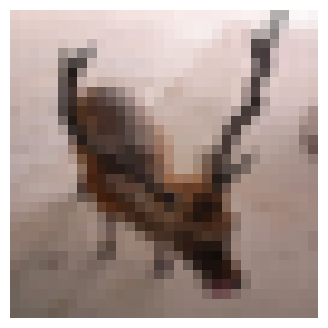

loss: 0.0000    true: deer    pred: deer
loss: 0.0035    true: deer    pred: deer
loss: 0.0000    true: deer    pred: deer
loss: 0.5151    true: deer    pred: deer
loss: 0.0000    true: deer    pred: deer
loss: 0.0022    true: deer    pred: deer
loss: -0.0000    true: deer    pred: deer
loss: 0.0119    true: deer    pred: deer
loss: 1.6815    true: deer    pred: airplane
loss: 0.0004    true: deer    pred: deer
loss: 0.0000    true: deer    pred: deer
loss: 0.0247    true: deer    pred: deer
loss: 0.0098    true: deer    pred: deer
loss: 1.0654    true: deer    pred: airplane
loss: 0.0000    true: deer    pred: deer
loss: 1.8673    true: deer    pred: airplane


[3919,
 35634,
 6613,
 8970,
 10728,
 18110,
 10951,
 41246,
 29083,
 14644,
 9931,
 14396,
 18115,
 40650,
 33669,
 22195]

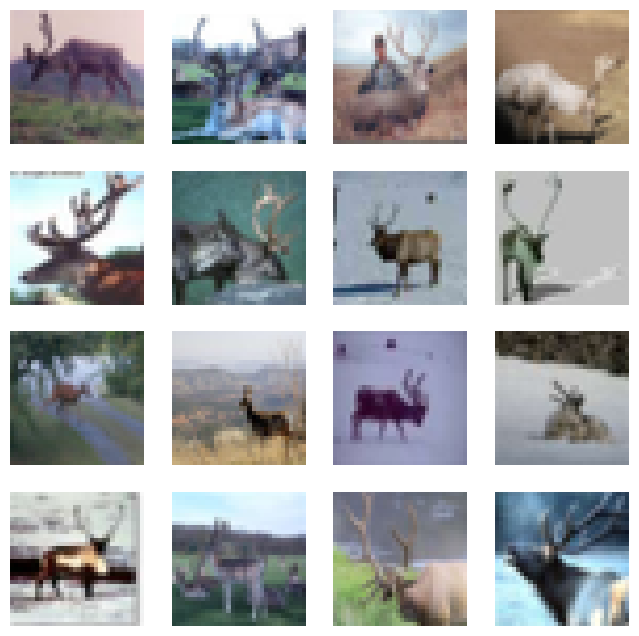

In [20]:
sample_loss_rank = 10
ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = test_ds[ref_sample_idx]
target_ds = train_ds

f = get_batch_grad_cos_fn(model, ref_input, ref_label)

plot_topk_info(target_ds, f, batch_size=512)

In [ ]:
def compute_batch_logits(model, params, buffers, inputs):
	return functional_call(model, (params, buffers), inputs)

def get_param_jac(model: nn.Module, inputs: Tensor):
    """
    返回形状: (batch_size, output_dim, total_params)
    使用 vmap+jacrev 降低显存占用
    """
    params, buffers = dict(model.named_parameters()), dict(model.named_buffers())

    # 单样本 Jacobian
    def single_jac(x):
        jacs = jacrev(compute_batch_logits, argnums=1)(model, params, buffers, x.unsqueeze(0))
        # 拼接到一个 tensor
        jacob_views = [jac.reshape(1, jac.shape[1], -1) for jac in jacs.values()]
        return torch.cat(jacob_views, dim=2)  # (1, out_dim, P)

    # vmap 按 batch 并行
    jacob_all = vmap(single_jac)(inputs)  # (B, 1, out_dim, P)
    jacob_all = jacob_all.squeeze(1)      # (B, out_dim, P)

    return jacob_all

In [ ]:
def get_batch_entk_fn(model, 
						   ref_input,
						   loss_fn=nn.CrossEntropyLoss(reduction='none'), 
						   device='cuda'):
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')
	model = model.to(device)

	ref_input = ref_input.to(device).unsqueeze(0)

	ref_jacob = get_param_jac(model, ref_input)   # (1, out_dim, P)
	
	def f(batch):
		inputs, labels = batch
		inputs, labels = inputs.to(device), labels.to(device)

		jacobs = get_param_jac(model, inputs)
		entk = torch.einsum('bop,aqp->boq', jacobs, ref_jacob)
		
		return entk
		# return torch.linalg.norm(entk, ord='fro', dim=(1, 2))
	return f

In [ ]:
def get_batch_entkFnorm_fn(model, 
						   ref_input,
						   loss_fn=nn.CrossEntropyLoss(reduction='none'), 
						   device='cuda'):
	entk_fn = get_batch_entk_fn(model, ref_input, loss_fn, device)
	return lambda batch: torch.linalg.norm(entk_fn(batch), ord='fro', dim=(1, 2))

In [ ]:
sample_loss_rank = 7
ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = train_ds[ref_sample_idx]
target_ds = train_ds

f = get_batch_entkFnorm_fn(model, ref_input)

In [ ]:
plot_topk_info(target_ds, f, batch_size=32)

In [ ]:
sample_loss_rank = 10
ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = test_ds[ref_sample_idx]
target_ds = train_ds

f = get_batch_entkFnorm_fn(model, ref_input)
plot_topk_info(target_ds, f, batch_size=64, print_sims=True)

In [ ]:
indices = [18080, 39739, 6380, 5323, 116, 1759, 49723, 1012,
 		   25995, 39292, 13815, 5082, 34693, 5343, 12296, 31970]

imgs, labels = zip(*[train_ds[i] for i in indices])  # 解包 (tensor, label)
imgs = torch.stack(imgs)      # 形状: (B, C, H, W)
labels = torch.tensor(labels) # 形状: (B,)

entk_fn = get_batch_entk_fn(model, ref_input)
entks = entk_fn((imgs, labels))

In [ ]:

def print_rows_aligned(t: torch.Tensor):
    # 确保是二维张量
    if t.dim() != 2:
        raise ValueError("Only 2D tensors are supported")
    
    # 转为整数（去掉小数部分），再转为 Python 列表方便格式化
    arr = t.to(torch.int).tolist()

    # 计算每列的最大宽度（按字符串长度）
    col_widths = [max(len(str(row[i])) for row in arr) for i in range(t.size(1))]

    # 按列宽格式化输出
    for row in arr:
        formatted_row = ", ".join(f"{val:>{col_widths[i]}}" for i, val in enumerate(row))
        print(f"tensor([{formatted_row}])")

In [ ]:
print_rows_aligned(entks[0])

In [ ]:
print_rows_aligned(entks[9])

In [21]:
recover_cuda_after_oom()

22807
✅ CUDA 显存已尝试回收


In [ ]:
sample_loss_rank = 10
sample_idx = test_hloss_samples[sample_loss_rank][1]
input, label = test_ds[sample_idx]

input_ = input.unsqueeze(0)   # (1, C, H, W)
label_ = torch.tensor([label], dtype=torch.long) 

device = 'cuda'
input_ = input_.to(device)
label_ = label_.to(device)
model = model.to(device)
model.eval()

output = model(input_).squeeze(0)
print(output)

In [1]:
recover_cuda_after_oom()

NameError: name 'recover_cuda_after_oom' is not defined